<a href="https://colab.research.google.com/github/sota-it/point-source-method/blob/main/HS%26PAS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

--> HS: 各観測角度からの像再生を計算中...


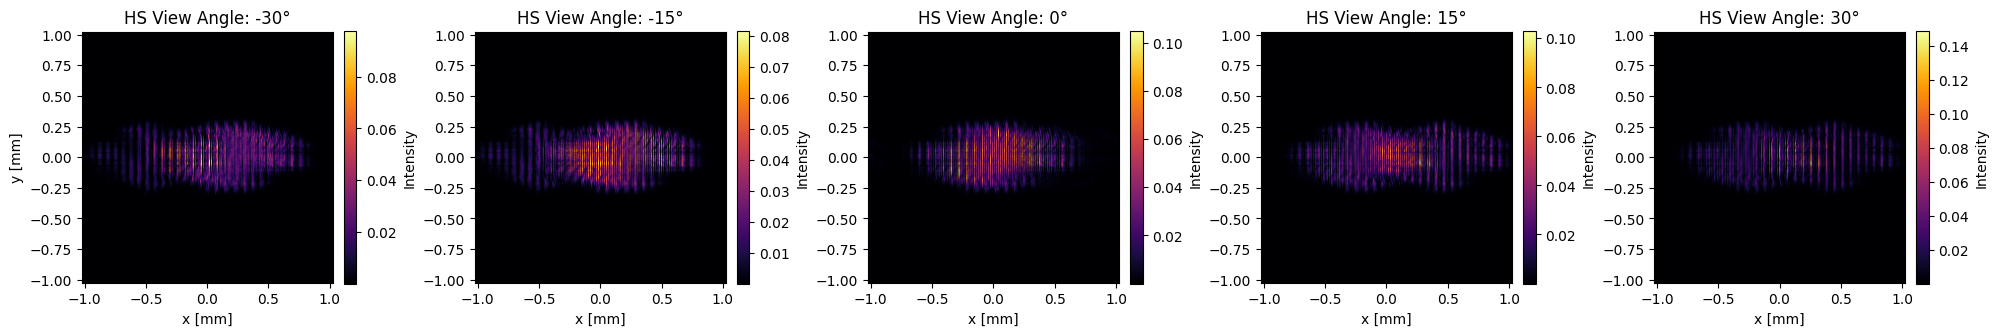

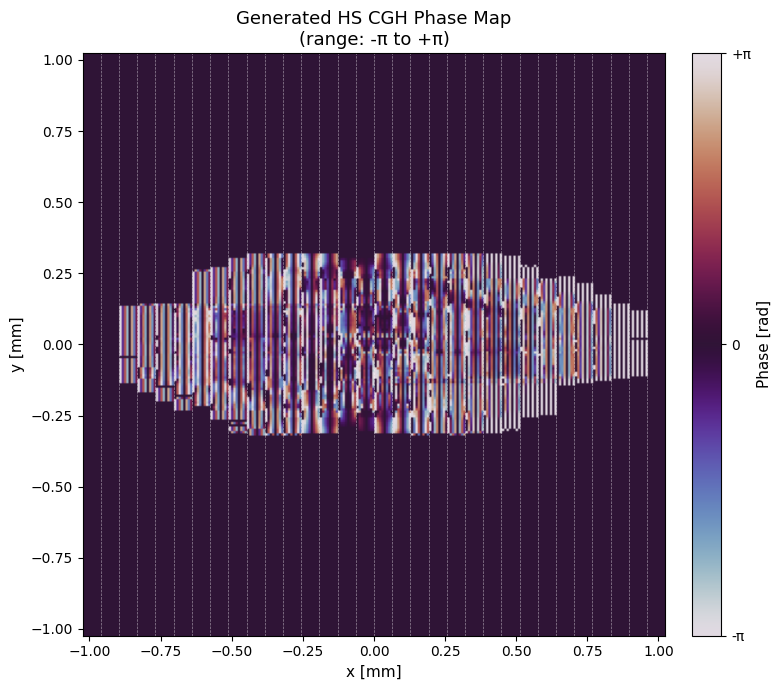

In [32]:
import glob
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

# =====================================================================
# 1. 光学系・ホログラムの物理パラメータ設定
# =====================================================================
wavelength = 633e-9          # 光の波長 λ: 633 nm (He-Neレーザー)
pitch = 8e-6                 # SLM のピクセルピッチ [m] (8 um)
z_prop = 0.005               # 再生距離 z [m] (0.5 cm)
k = 2 * np.pi / wavelength

# =====================================================================
# 2. 多視点画像群 (Light Field) の読み込み & テンソル構築
# =====================================================================
image_folder = "/content/multiview_output/"
image_paths = sorted(glob.glob(os.path.join(image_folder, "view_*.png")))

if len(image_paths) == 0:
    raise FileNotFoundError(f"'{image_folder}' 内に 'view_*.png' が見つかりませんでした。")

sample_img = cv2.imread(image_paths[0], cv2.IMREAD_GRAYSCALE)
N_y, N_x = sample_img.shape

num_views = len(image_paths)        # 視点数 = 32
num_hogels = num_views              # Hogel 数 = 32
hogel_size = N_x // num_hogels      # 1 Hogel あたりのピクセル数 = 8 px

light_field_list = [cv2.imread(p, cv2.IMREAD_GRAYSCALE).astype(np.float32) / 255.0 for p in image_paths]
light_field = np.stack(light_field_list, axis=0)

# =====================================================================
# 3. Holographic Stereogram (HS) の波面計算
# =====================================================================
cgh_hs = np.zeros((N_y, N_x), dtype=np.complex64)

for hy in range(N_y):
    for hx in range(num_hogels):
        x_start = hx * hogel_size
        x_end = (hx + 1) * hogel_size

        # 1. 該当 Hogel パッチにおける視点ごとの光線強度を取得
        ray_profile = light_field[:, hy, x_start:x_end].mean(axis=1)

        # 2. 光線の角度サンプリング数を Hogel 幅 (8px) にリサイズ
        ray_resampled = np.interp(
            np.linspace(0, num_views - 1, hogel_size),
            np.arange(num_views),
            ray_profile
        )

        # 振幅スペクトル
        amplitude_spectrum = np.sqrt(np.maximum(ray_resampled, 0.0))

        # 3. 1次元逆フーリエ変換による要素波面の合成 (HS: 位相加算なし)
        hogel_wavefront = np.fft.ifftshift(np.fft.ifft(np.fft.fftshift(amplitude_spectrum)))

        # 4. ホログラム配列へ配置
        cgh_hs[hy, x_start:x_end] = hogel_wavefront

# =====================================================================
# 4. 指定角度からの像再生関数 (角スペクトル法: ASM + キャリア位相)
# =====================================================================
def propagate_asm_tilted(u_in, z, wavelength, pitch, theta_deg):
    Ny, Nx = u_in.shape
    theta_rad = np.radians(theta_deg)

    # 物理空間座標
    x = (np.arange(Nx) - Nx // 2) * pitch
    y = (np.arange(Ny) - Ny // 2) * pitch
    X, Y = np.meshgrid(x, y)

    # 観測角度 θ に応じたキャリア位相（位相傾き）
    tilt_phase = np.exp(-1j * k * np.sin(theta_rad) * X)
    u_tilted = u_in * tilt_phase

    # 角スペクトル法 (ASM)
    dfx = 1.0 / (Nx * pitch)
    dfy = 1.0 / (Ny * pitch)

    fx = (np.arange(Nx) - Nx // 2) * dfx
    fy = (np.arange(Ny) - Ny // 2) * dfy
    FX, FY = np.meshgrid(fx, fy)

    sq = 1.0 - (wavelength * FX)**2 - (wavelength * FY)**2
    sq[sq < 0] = 0.0
    H = np.exp(1j * k * z * np.sqrt(sq))

    U_freq = np.fft.fftshift(np.fft.fft2(np.fft.ifftshift(u_tilted)))
    U_prop_freq = U_freq * H
    u_out = np.fft.fftshift(np.fft.ifft2(np.fft.ifftshift(U_prop_freq)))

    return u_out

# =====================================================================
# 5. 各観測角度（-30°, -15°, 0°, 15°, 30°）での HS 再生と可視化
# =====================================================================
angles = [-30, -15, 0, 15, 30]
fig, axes = plt.subplots(1, len(angles), figsize=(20, 4.5))

extent_mm = [-N_x*pitch/2*1e3, N_x*pitch/2*1e3, -N_y*pitch/2*1e3, N_y*pitch/2*1e3]

print("--> HS: 各観測角度からの像再生を計算中...")

for idx, angle in enumerate(angles):
    rec_wave = propagate_asm_tilted(cgh_hs, z_prop, wavelength, pitch, angle)
    rec_intensity = np.abs(rec_wave) ** 2

    i_min, i_max = rec_intensity.min(), rec_intensity.max()

    # 表示
    im = axes[idx].imshow(rec_intensity, cmap='inferno', extent=extent_mm)
    axes[idx].set_title(f"HS View Angle: {angle}°")
    axes[idx].set_xlabel("x [mm]")
    if idx == 0:
        axes[idx].set_ylabel("y [mm]")

    # 各角度のプロットに Max-Min が分かるカラーバーを追加
    cbar = fig.colorbar(im, ax=axes[idx], fraction=0.046, pad=0.04)
    cbar.set_label("Intensity")

plt.tight_layout()
plt.show()

# =====================================================================
# 6. HS ホログラム（HS Phase Map）の単体表示 (-π 〜 +π 目盛り設定)
# =====================================================================
phase_map_hs = np.angle(cgh_hs)

fig, ax = plt.subplots(figsize=(8, 7))

im = ax.imshow(
    phase_map_hs,
    cmap='twilight',
    extent=extent_mm,
    aspect='equal',
    vmin=-np.pi,
    vmax=np.pi               # 位相範囲を -π 〜 +π に固定
)

# 各 Hogel の境界線（破線）
for hx in range(1, num_hogels):
    x_pos_mm = (-N_x / 2 + hx * hogel_size) * pitch * 1e3
    ax.axvline(x=x_pos_mm, color='white', linestyle='--', linewidth=0.5, alpha=0.5)

ax.set_title("Generated HS CGH Phase Map\n(range: -π to +π)", fontsize=13)
ax.set_xlabel("x [mm]", fontsize=11)
ax.set_ylabel("y [mm]", fontsize=11)

# カラーバーの単位・目盛りを -π, 0, +π に設定
cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("Phase [rad]", fontsize=11)
cbar.set_ticks([-np.pi, 0, np.pi])
cbar.set_ticklabels(['-π', '0', '+π'])

plt.tight_layout()
plt.show()

--> PAS: 各観測角度からの像再生を計算中...


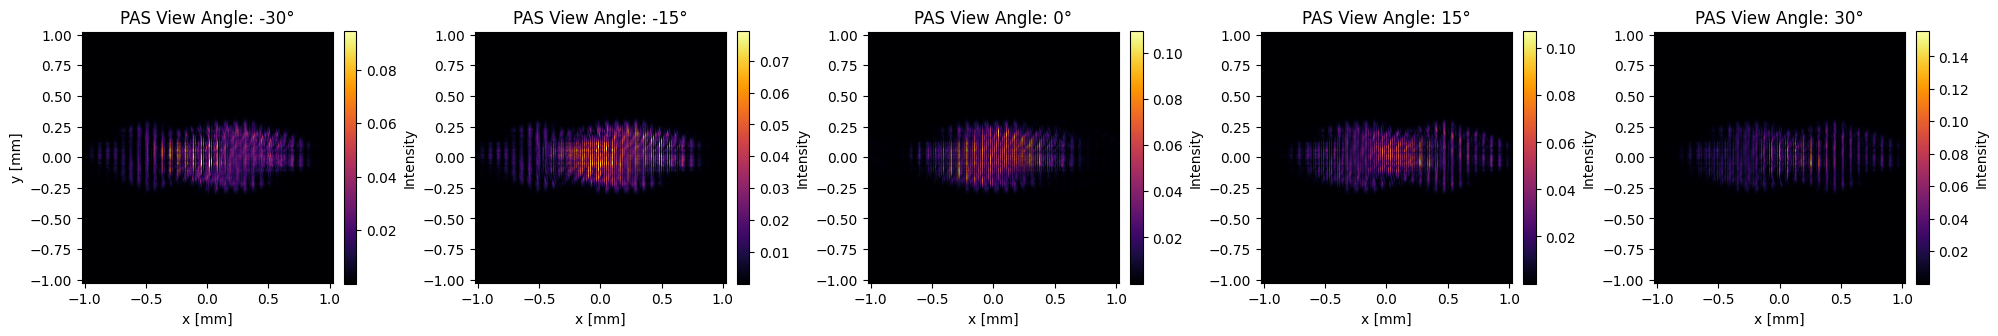

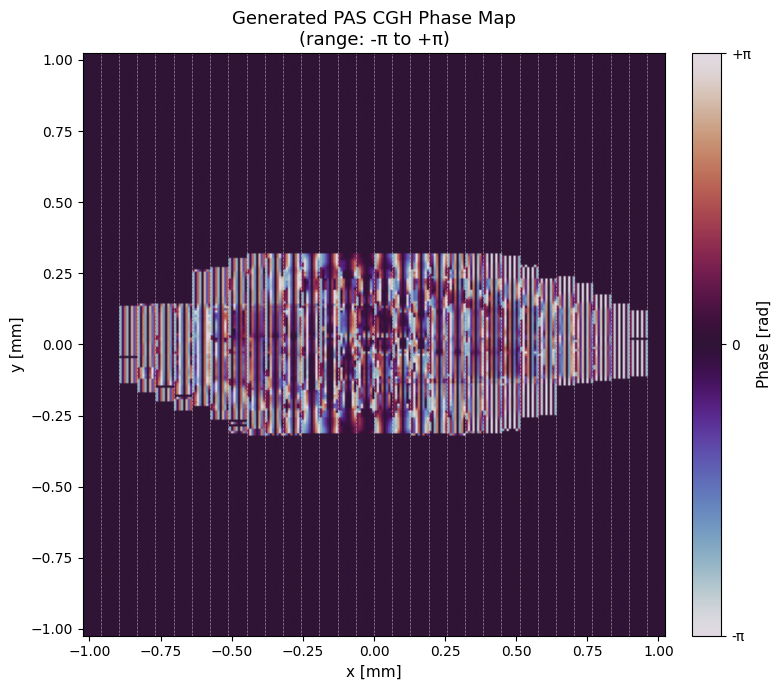

In [33]:
import glob
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

# =====================================================================
# 1. パラメータ設定
# =====================================================================
wavelength = 633e-9          # 光の波長 λ: 633 nm
pitch = 8e-6                 # SLM ピクセルピッチ: 8 um
z_prop = 0.005               # 物体再生距離 z: 0.5 cm (5 mm)
k = 2 * np.pi / wavelength

# =====================================================================
# 2. 多視点画像群 (Light Field) の読み込み
# =====================================================================
image_folder = "/content/multiview_output/"
image_paths = sorted(glob.glob(os.path.join(image_folder, "view_*.png")))

if len(image_paths) == 0:
    raise FileNotFoundError("画像ファイルが見つかりません。パスを確認してください。")

sample_img = cv2.imread(image_paths[0], cv2.IMREAD_GRAYSCALE)
N_y, N_x = sample_img.shape

num_views = len(image_paths)
num_hogels = num_views
hogel_size = N_x // num_hogels

light_field_list = [cv2.imread(p, cv2.IMREAD_GRAYSCALE).astype(np.float32) / 255.0 for p in image_paths]
light_field = np.stack(light_field_list, axis=0)

# =====================================================================
# 3. PAS ホログラム（cgh_pas）の波面計算
# =====================================================================
cgh_pas = np.zeros((N_y, N_x), dtype=np.complex64)

# 各 Hogel 内のローカル空間座標 [m]
x_hogel_local = (np.arange(hogel_size) - (hogel_size - 1) / 2.0) * pitch

# PAS の位相加算項 (Phase-Add Term)
phase_add_term = np.exp(1j * (k / (2.0 * z_prop)) * (x_hogel_local ** 2))

for hy in range(N_y):
    for hx in range(num_hogels):
        x_start = hx * hogel_size
        x_end = (hx + 1) * hogel_size

        # 光線プロファイルの抽出とサンプリング
        ray_profile = light_field[:, hy, x_start:x_end].mean(axis=1)
        ray_resampled = np.interp(
            np.linspace(0, num_views - 1, hogel_size),
            np.arange(num_views),
            ray_profile
        )

        amplitude_spectrum = np.sqrt(np.maximum(ray_resampled, 0.0))

        # 要素波面 (IFFT) + 位相加算 (PAS)
        hogel_wavefront = np.fft.ifftshift(np.fft.ifft(np.fft.fftshift(amplitude_spectrum)))
        cgh_pas[hy, x_start:x_end] = hogel_wavefront * phase_add_term

# =====================================================================
# 4. 指定角度からの像再生処理 (角スペクトル法: ASM + キャリア位相)
# =====================================================================
def propagate_asm_tilted(u_in, z, wavelength, pitch, theta_deg):
    Ny, Nx = u_in.shape
    theta_rad = np.radians(theta_deg)

    # 物理空間座標
    x = (np.arange(Nx) - Nx // 2) * pitch
    y = (np.arange(Ny) - Ny // 2) * pitch
    X, Y = np.meshgrid(x, y)

    # 観測角度 θ に応じたキャリア位相（位相傾き）
    tilt_phase = np.exp(-1j * k * np.sin(theta_rad) * X)
    u_tilted = u_in * tilt_phase

    # 角スペクトル法 (ASM)
    dfx = 1.0 / (Nx * pitch)
    dfy = 1.0 / (Ny * pitch)

    fx = (np.arange(Nx) - Nx // 2) * dfx
    fy = (np.arange(Ny) - Ny // 2) * dfy
    FX, FY = np.meshgrid(fx, fy)

    sq = 1.0 - (wavelength * FX)**2 - (wavelength * FY)**2
    sq[sq < 0] = 0.0
    H = np.exp(1j * k * z * np.sqrt(sq))

    U_freq = np.fft.fftshift(np.fft.fft2(np.fft.ifftshift(u_tilted)))
    U_prop_freq = U_freq * H
    u_out = np.fft.fftshift(np.fft.ifft2(np.fft.ifftshift(U_prop_freq)))

    return u_out

# =====================================================================
# 5. 各角度（-30°, -15°, 0°, 15°, 30°）での PAS 再生と可視化
# =====================================================================
angles = [-30, -15, 0, 15, 30]
fig, axes = plt.subplots(1, len(angles), figsize=(20, 4.5))

extent_mm = [-N_x*pitch/2*1e3, N_x*pitch/2*1e3, -N_y*pitch/2*1e3, N_y*pitch/2*1e3]

print("--> PAS: 各観測角度からの像再生を計算中...")

for idx, angle in enumerate(angles):
    rec_wave = propagate_asm_tilted(cgh_pas, z_prop, wavelength, pitch, angle)
    rec_intensity = np.abs(rec_wave) ** 2

    i_min, i_max = rec_intensity.min(), rec_intensity.max()

    # 表示
    im = axes[idx].imshow(rec_intensity, cmap='inferno', extent=extent_mm)
    axes[idx].set_title(f"PAS View Angle: {angle}°")
    axes[idx].set_xlabel("x [mm]")
    if idx == 0:
        axes[idx].set_ylabel("y [mm]")

    # 各角度のプロットに Max-Min が分かるカラーバーを追加
    cbar = fig.colorbar(im, ax=axes[idx], fraction=0.046, pad=0.04)
    cbar.set_label("Intensity")

plt.tight_layout()
plt.show()

# =====================================================================
# 6. PAS ホログラム（PAS Phase Map）の単体表示 (-π 〜 +π 目盛り設定)
# =====================================================================
phase_map_pas = np.angle(cgh_pas)

fig, ax = plt.subplots(figsize=(8, 7))

im = ax.imshow(
    phase_map_pas,
    cmap='twilight',
    extent=extent_mm,
    aspect='equal',
    vmin=-np.pi,
    vmax=np.pi               # 位相範囲を -π 〜 +π に固定
)

# 各 Hogel の境界線（破線）
for hx in range(1, num_hogels):
    x_pos_mm = (-N_x / 2 + hx * hogel_size) * pitch * 1e3
    ax.axvline(x=x_pos_mm, color='white', linestyle='--', linewidth=0.5, alpha=0.5)

ax.set_title("Generated PAS CGH Phase Map\n(range: -π to +π)", fontsize=13)
ax.set_xlabel("x [mm]", fontsize=11)
ax.set_ylabel("y [mm]", fontsize=11)

# カラーバーの単位・目盛りを -π, 0, +π に設定
cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("Phase [rad]", fontsize=11)
cbar.set_ticks([-np.pi, 0, np.pi])
cbar.set_ticklabels(['-π', '0', '+π'])

plt.tight_layout()
plt.show()